In [14]:
import numpy as np

def integrate_rec(f, a, b, n):
    # Implementasi metode persegi panjang (rectangle method)
    h = (b - a) / n
    x = np.linspace(a, b, n + 1) 
    i = 0
    area = 0
    while i < n:
        sup_rect = f(x[i]) * h
        area += sup_rect
        i += 1 
    return area

'''
menguji metode Rectangle pada fungsi sinus,
di mana integral tentu pada interval [0, π/2] bernilai 1.
'''

sup_5 = integrate_rec(np.sin, 0, np.pi/2, 5)
sup_10 = integrate_rec(np.sin, 0, np.pi/2, 10)
sup_100 = integrate_rec(np.sin, 0, np.pi/2, 100)

print('Using n=5, the rectangle method returns a value of {:.2f}'.format(sup_5))
print('Using n=10, the rectangle method returns a value of {:.2f}'.format(sup_10))
print('Using n=100, the rectangle method returns a value of {:.2f}'.format(sup_100))

Using n=5, the rectangle method returns a value of 0.83
Using n=10, the rectangle method returns a value of 0.92
Using n=100, the rectangle method returns a value of 0.99


In [13]:
import numpy as np

def integrate_trap(f, a, b, n):
    # Implementasi metode trapesium (trapezoidal rule)
    h = (b - a) / n
    x = np.linspace(a, b, n + 1) 
    i = 1
    area = h * (f(x[0]) + f(x[n])) / 2
    while i < n:
        sup_rect = f(x[i]) * h
        area += sup_rect 
        i += 1 
    return area

'''
menguji metode trapesium pada fungsi sinus,
di mana integral tentu pada interval [0, π/2] bernilai 1.
'''

sup_5 = integrate_trap(np.sin, 0, np.pi/2, 5)
sup_10 = integrate_trap(np.sin, 0, np.pi/2, 10)

print('Using n=5, the trapezoidal rule returns a value of {:.2f}'.format(sup_5))
print('Using n=10, the trapezoidal rule returns a value of {:.2f}'.format(sup_10))

Using n=5, the trapezoidal rule returns a value of 0.99
Using n=10, the trapezoidal rule returns a value of 1.00


In [1]:
import numpy as np
from scipy import integrate

# Membuat 5 titik (n=4 interval): [x0, x1, x2, x3, x4]
x = np.linspace(0, 8, 5)

# Fungsi yang akan diintegralkan: f(x) = x^3
y = x**3

# Menghitung integral dengan metode trapesium
# Trapesium menghubungkan titik-titik dengan garis lurus
sup_trapz = integrate.trapezoid(y, x)

# Menghitung integral dengan metode Simpson
# Simpson menyesuaikan kurva dengan parabola antar titik
sup_simps = integrate.simpson(y, x)

# Menampilkan hasil
print('Using n=4, the trapezoidal rule returns a value of {:.2f}'.format(sup_trapz))
print('Using n=4, the composite Simpson rule returns a value of {:.2f}'.format(sup_simps))

Using n=4, the trapezoidal rule returns a value of 1088.00
Using n=4, the composite Simpson rule returns a value of 1024.00


In [3]:
import numpy as np
from scipy import integrate

# luas kontur (dalam meter²)
contours_areas = np.array([180000, 145000, 90000, 50000, 25000, 12000, 5000])

# Posisi setiap kontur baru (jarak antar kontur dalam meter)
x = np.array([0, 20, 40, 60, 80, 100, 120])

# Menghitung volume menggunakan metode trapesium
vol_traps = integrate.trapezoid(contours_areas, x)

# Menghitung volume menggunakan metode Simpson
vol_simps = integrate.simpson(contours_areas, x)

# Menampilkan hasil
print('The trapezoidal rule returns a volume of {:.0f} cubic meters'.format(vol_traps))
print('The composite Simpson rule returns a volume of {:.0f} cubic meters'.format(vol_simps))

The trapezoidal rule returns a volume of 8290000 cubic meters
The composite Simpson rule returns a volume of 8286667 cubic meters


In [4]:
# Fungsi untuk menghitung tekanan litostatik sederhana
# z   : kedalaman (m)
# ro  : densitas batuan (kg/m³), default 2900
# g   : percepatan gravitasi (m/s²), default 9.8
def simple_lithopress(z, ro=2900, g=9.8):
    # Tekanan = kedalaman × densitas × gravitasi, dikonversi ke MPa
    pressure = z * g * ro / 1e6  # 1e6 untuk konversi Pa → MPa
    return pressure

# menghitung tekanan pada kedalaman 2000 m
my_pressure = simple_lithopress(z=2000)

# Menampilkan hasil
print('The pressure at 2000 meters is {0:.0f} MPa'.format(my_pressure))

The pressure at 2000 meters is 57 MPa


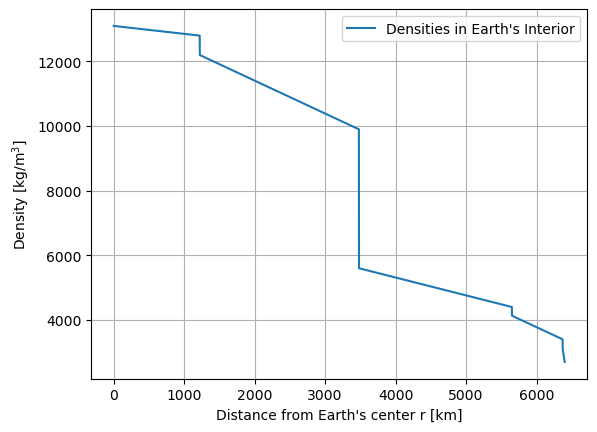

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Membuat jarak dari pusat Bumi hingga permukaan (km)
r = np.linspace(1, 6400, 6400)  # 6400 km radius Bumi

# Fungsi untuk membuat profil densitas interior Bumi
def density():
    # Densitas tiap lapisan (kg/m³)
    ro_inner_core   = np.linspace(13100, 12800, 1220)  # inti dalam
    ro_outer_core   = np.linspace(12200, 9900, 2259)   # inti luar
    ro_lower_mantle = np.linspace(5600, 4400, 2171)    # mantel bawah
    ro_upper_mantle = np.linspace(4130, 3400, 720)     # mantel atas
    ro_crust        = np.linspace(3100, 2700, 30)      # kerak bumi
    
    # Gabungkan semua lapisan menjadi satu array
    ro_final = np.concatenate((ro_inner_core, ro_outer_core, ro_lower_mantle, ro_upper_mantle, ro_crust))
    
    return ro_final

# Mendapatkan array densitas
ro = density()

# Membuat plot
fig, ax = plt.subplots()
ax.plot(r, ro, label="Densities in Earth's Interior")
ax.set_ylabel(r"Density [kg/m$^3$]")
ax.set_xlabel("Distance from Earth's center r [km]")
ax.legend()
ax.grid(True)
plt.show()

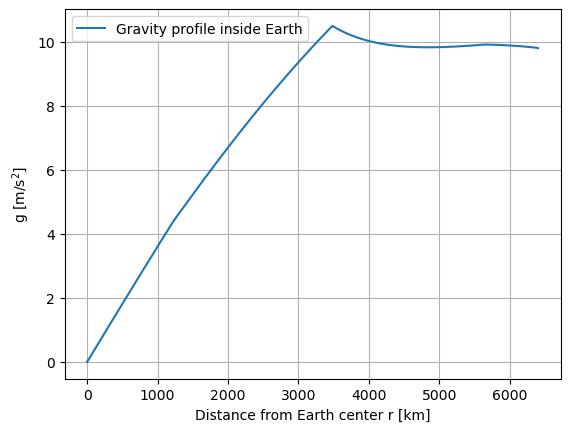

In [8]:
import numpy as np
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt

# Fungsi untuk menghitung percepatan gravitasi di setiap radius
def gravity(r, ro):
    """
    r  : array jarak dari pusat Bumi (km)
    ro : array densitas di setiap titik r (kg/m³)
    
    return : array percepatan gravitasi (m/s²)
    """
    g = np.zeros(len(r))
    Gr = 6.67408e-11  # konstanta gravitasi (m³/kg/s²)
    
    r_m = r * 1000  # konversi km → m
    
    for i in range(1, len(r)):
        r1 = r_m[0:i]       # subarray radius dari pusat sampai titik ke-i
        ro1 = ro[0:i]       # densitas sesuai radius
        r2 = r_m[i-1]       # radius saat ini
        
        # Integral numerik: 4π ∫ρ(r) r² dr
        y = ro1 * r1**2
        y_int = trapezoid(y, r1)
        
        # Percepatan gravitasi di titik r2
        g1 = (4 * np.pi * Gr / r2**2) * y_int
        g[i] = g1
           
    return g

# Hitung percepatan gravitasi
g = gravity(r, ro)

# Plot hasil
fig, ax = plt.subplots()
ax.plot(r, g, label="Gravity profile inside Earth")
ax.grid(True)
ax.set_ylabel(r'g [m/s$^2$]')
ax.set_xlabel('Distance from Earth center r [km]')
ax.legend()
plt.show()

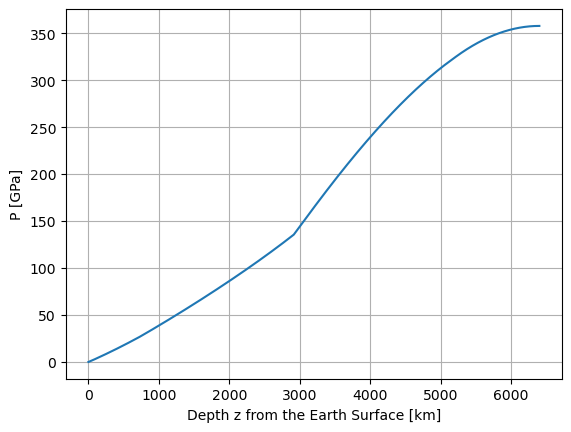

In [11]:
import numpy as np
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt

# Fungsi untuk menghitung tekanan di dalam Bumi
def pressure(r, ro, g):
    """
    r  : jarak dari pusat Bumi (km)
    ro : densitas (kg/m³)
    g  : percepatan gravitasi (m/s²)
    
    return : tekanan (Pa)
    """
    p = np.zeros(len(r))
    r = r * 1000  # konversi km → m
    
    for i in range(0, len(r)):    
        # Mengambil bagian dari titik i sampai permukaan
        r1 = r[i:len(r)]
        ro1 = ro[i:len(r)]
        g1 = g[i:len(r)]
        
        # Integrasi tekanan: ∫ ρ g dr
        y = ro1 * g1
        p1 = trapezoid(y, r1)
        
        p[i] = p1
        
    return p

# Menghitung tekanan dan mengubah ke GPa
p = pressure(r, ro, g) / 1e9  # dari Pa → GPa

# Mengubah radius menjadi kedalaman dari permukaan
z = np.linspace(6400, 1, 6400)

# Plot hasil
fig, ax = plt.subplots()  
ax.plot(z, p)
ax.grid(True)
ax.set_ylabel('P [GPa]')
ax.set_xlabel('Depth z from the Earth Surface [km]')
plt.show()